In [ ]:
# Load Saved Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../data/processed/four_cities_raw.csv')
df['datetime'] = pd.to_datetime(df['datetime'])

print(f"Loaded: {df.shape}")
print(df['city'].value_counts())

Loaded: (6096841, 13)
city
Delhi        2796171
Mumbai       1536739
Bengaluru    1332059
Hyderabad     431872
Name: count, dtype: int64


In [2]:
# Resample to daily averages per station
# Group by city, station, date and take daily mean
df['date'] = df['datetime'].dt.date

daily = df.groupby(['city', 'station', 'date']).agg({
    'PM25': 'mean',
    'PM10': 'mean',
    'NO': 'mean',
    'NO2': 'mean',
    'NOx': 'mean',
    'NH3': 'mean',
    'SO2': 'mean',
    'CO': 'mean',
    'Ozone': 'mean',
    'Benzene': 'mean'
}).reset_index()

daily['date'] = pd.to_datetime(daily['date'])
daily = daily.sort_values(['city', 'station', 'date']).reset_index(drop=True)

print(f"Resampled to daily!")
print(f"Shape: {daily.shape}")
print(daily.head())

Resampled to daily!
Shape: (254092, 13)
        city station       date  PM25  PM10        NO        NO2        NOx  \
0  Bengaluru   KA001 2010-01-03   NaN   NaN  8.819000  51.296000  60.115000   
1  Bengaluru   KA001 2010-01-04   NaN   NaN  6.205833  28.812500  35.019167   
2  Bengaluru   KA001 2010-01-05   NaN   NaN  5.720000  34.114615  39.810769   
3  Bengaluru   KA001 2010-01-06   NaN   NaN  6.465000  31.979500  38.345000   
4  Bengaluru   KA001 2010-01-07   NaN   NaN  4.423478  21.496087  25.815652   

   NH3       SO2        CO      Ozone   Benzene  
0  NaN  0.877143  1.203333  54.997000       NaN  
1  NaN  2.107143  0.256364  46.744167  6.010000  
2  NaN  1.133846  0.441538  76.332308  2.297273  
3  NaN  0.312222  0.399000  66.706500  3.408889  
4  NaN  0.812273  0.490526  71.590435       NaN  


In [3]:
# Handle Missing Values with Interpolation
pollutants = ['PM25', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'SO2', 'CO', 'Ozone', 'Benzene']

# Interpolate per station (time-based)
filled = []

for (city, station), group in daily.groupby(['city', 'station']):
    group = group.sort_values('date').copy()
    # Linear interpolation then fill remaining with forward/backward fill
    group[pollutants] = group[pollutants].interpolate(method='linear', limit=24)
    group[pollutants] = group[pollutants].ffill().bfill()
    filled.append(group)

daily = pd.concat(filled, ignore_index=True)

# Check remaining missing
missing = (daily[pollutants].isnull().sum() / len(daily) * 100).round(2)
print("Remaining missing % after interpolation:")
print(missing)

Remaining missing % after interpolation:
PM25        3.19
PM10        2.55
NO          3.46
NO2         0.00
NOx         6.51
NH3        25.66
SO2        15.24
CO          5.74
Ozone       4.11
Benzene    10.79
dtype: float64


In [5]:
# Feature engineering
daily['month'] = daily['date'].dt.month
daily['day_of_week'] = daily['date'].dt.dayofweek
daily['year'] = daily['date'].dt.year
daily['quarter'] = daily['date'].dt.quarter

# Add season
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8, 9]:
        return 'Monsoon'
    else:
        return 'Autumn'

daily['season'] = daily['month'].apply(get_season)

print(" Features added!")
print(daily[['date', 'city', 'month', 'season', 'day_of_week', 'year']].head(10))

 Features added!
        date       city  month  season  day_of_week  year
0 2010-01-03  Bengaluru      1  Winter            6  2010
1 2010-01-04  Bengaluru      1  Winter            0  2010
2 2010-01-05  Bengaluru      1  Winter            1  2010
3 2010-01-06  Bengaluru      1  Winter            2  2010
4 2010-01-07  Bengaluru      1  Winter            3  2010
5 2010-01-08  Bengaluru      1  Winter            4  2010
6 2010-01-09  Bengaluru      1  Winter            5  2010
7 2010-01-10  Bengaluru      1  Winter            6  2010
8 2010-01-11  Bengaluru      1  Winter            0  2010
9 2010-01-12  Bengaluru      1  Winter            1  2010


In [6]:
# City level daily average
# Average across all stations per city per day
city_daily = daily.groupby(['city', 'date', 'month', 'day_of_week', 'year', 'quarter', 'season'])[pollutants].mean().reset_index()
city_daily = city_daily.sort_values(['city', 'date']).reset_index(drop=True)

print(f"City level daily data ready!")
print(f"Shape: {city_daily.shape}")
print(f"\nRows per city:")
print(city_daily['city'].value_counts())

City level daily data ready!
Shape: (19018, 17)

Rows per city:
city
Bengaluru    4838
Delhi        4838
Mumbai       4838
Hyderabad    4504
Name: count, dtype: int64


In [7]:
# Save final clean datasets
# Save station level
daily.to_csv('../data/processed/station_daily_clean.csv', index=False)
print(f"Station level saved: {daily.shape}")

# Save city level
city_daily.to_csv('../data/processed/city_daily_clean.csv', index=False)
print(f"City level saved: {city_daily.shape}")

print(f"\nPreview of city daily:")
print(city_daily.head())

Station level saved: (254092, 18)
City level saved: (19018, 17)

Preview of city daily:
        city       date  month  day_of_week  year  quarter  season       PM25  \
0  Bengaluru 2010-01-01      1            4  2010        1  Winter  45.680481   
1  Bengaluru 2010-01-02      1            5  2010        1  Winter  45.680481   
2  Bengaluru 2010-01-03      1            6  2010        1  Winter  51.230321   
3  Bengaluru 2010-01-04      1            0  2010        1  Winter  51.230321   
4  Bengaluru 2010-01-05      1            1  2010        1  Winter  51.230321   

        PM10         NO        NO2        NOx        NH3       SO2        CO  \
0  89.866905   4.014167  19.772083  23.767917  26.069167  1.652000  0.699583   
1  89.866905   5.620625  22.989583  28.594375  25.741042  2.825000  0.695625   
2  92.751640   6.998417  30.434917  37.413889  15.048651  1.764325  0.771427   
3  92.751640  11.967222  31.255972  43.212083  24.080595  6.145159  0.610364   
4  92.751640  12.011667  

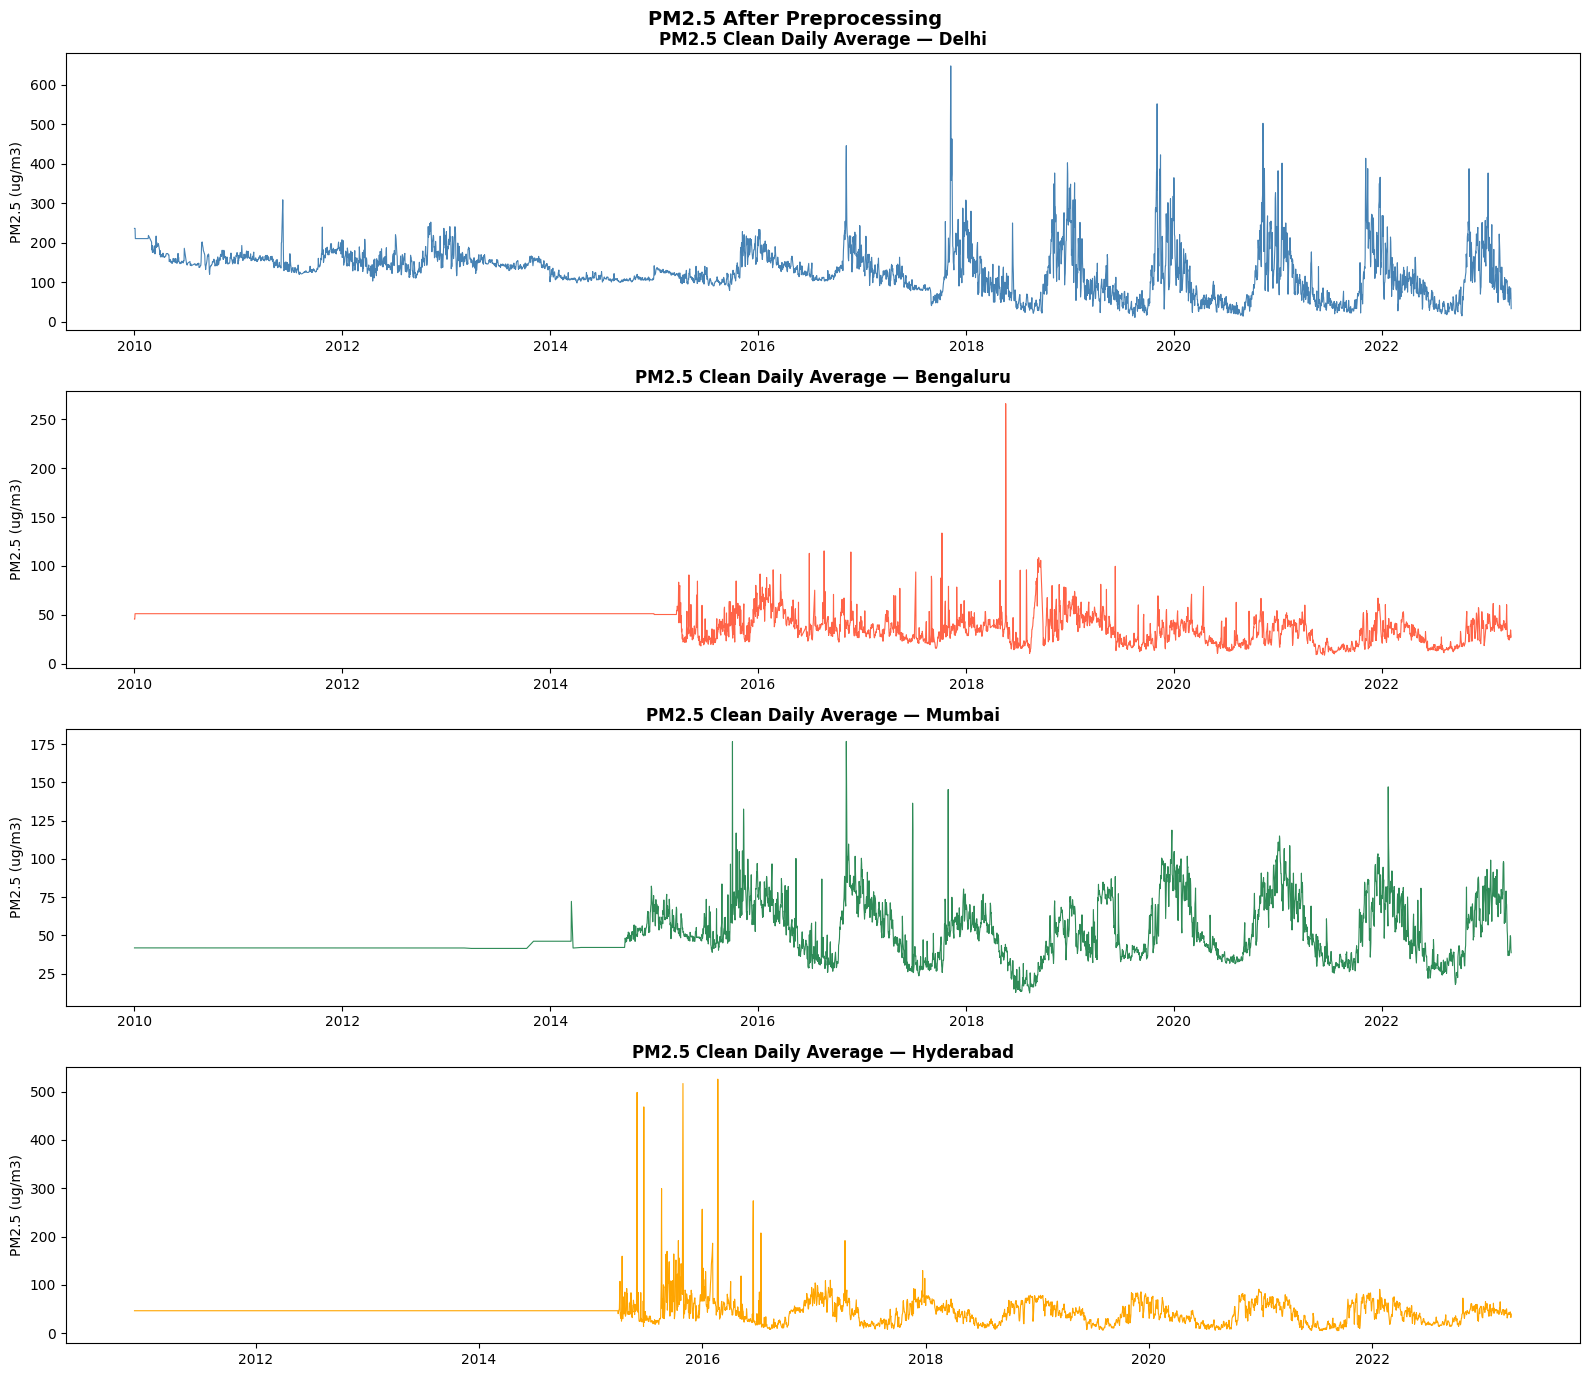

In [8]:
# Plot clean PM2.5 after preprocessing
fig, axes = plt.subplots(4, 1, figsize=(16, 14))
cities = ['Delhi', 'Bengaluru', 'Mumbai', 'Hyderabad']
colors = ['steelblue', 'tomato', 'seagreen', 'orange']

for ax, city, color in zip(axes, cities, colors):
    city_df = city_daily[city_daily['city'] == city]
    ax.plot(city_df['date'], city_df['PM25'], linewidth=0.8, color=color)
    ax.set_title(f'PM2.5 Clean Daily Average — {city}', fontweight='bold')
    ax.set_ylabel('PM2.5 (ug/m3)')

plt.suptitle('PM2.5 After Preprocessing', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()